### Topology + Demand Matrix

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

G = nx.DiGraph()

links = [
    ("A", "B", 10, 1),
    ("B", "A", 10, 1),
    ("A", "C", 5, 3),
    ("C", "A", 5, 3),
    ("B", "C", 10, 1),
    ("C", "B", 10, 1),
    ("B", "D", 5, 2),
    ("D", "B", 5, 2),
    ("C", "D", 10, 1),
    ("D", "C", 10, 1),
]

for u, v, cap, w in links:
    G.add_edge(u, v, capacity=cap, weight=w, usage=0)

demands = pd.DataFrame([
    ("A", "D", 4),
    ("A", "C", 2),
    ("B", "D", 3),
    ("C", "B", 1),
], columns=["src", "dst", "demand"])

print("Demand Matrix:")
display(demands)

Demand Matrix:


,src,dst,demand
0,A,D,4
1,A,C,2
2,B,D,3
3,C,B,1


### Routing + Link Usage Computation

In [2]:
def reset_usage(G):
    for u, v in G.edges():
        G[u][v]["usage"] = 0


def route_demands(G, demands, ecmp=False):
    reset_usage(G)

    for _, row in demands.iterrows():
        s, t, d = row["src"], row["dst"], row["demand"]

        if ecmp:
            paths = list(nx.all_shortest_paths(G, s, t, weight="weight"))
            split = d / len(paths)

            for path in paths:
                for i in range(len(path) - 1):
                    u, v = path[i], path[i+1]
                    G[u][v]["usage"] += split

        else:
            path = nx.shortest_path(G, s, t, weight="weight")

            for i in range(len(path) - 1):
                u, v = path[i], path[i+1]
                G[u][v]["usage"] += d

### Utilization Computation

In [3]:
def compute_utilization(G):
    results = []

    for u, v in G.edges():
        usage = G[u][v]["usage"]
        cap = G[u][v]["capacity"]
        util = usage / cap if cap > 0 else 0

        results.append({
            "link": f"{u}->{v}",
            "usage": usage,
            "capacity": cap,
            "utilization": util
        })

    df = pd.DataFrame(results)
    return df.sort_values(by="utilization", ascending=False)

### Visualization

In [4]:
def draw_graph(G, title="Network"):
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(6,5))
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue')

    edge_labels = {}
    for u, v in G.edges():
        usage = G[u][v]["usage"]
        cap = G[u][v]["capacity"]
        edge_labels[(u, v)] = f"{usage:.1f}/{cap}"

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title(title)
    plt.show()

### Execution - Initial Weights

=== Link Utilization ===


,link,usage,capacity,utilization
4,B->D,7,5,1.4
0,A->B,6,10,0.6
3,B->C,2,10,0.2
6,C->B,1,10,0.1
1,A->C,0,5,0.0
2,B->A,0,10,0.0
5,C->A,0,5,0.0
7,C->D,0,10,0.0
8,D->B,0,5,0.0
9,D->C,0,10,0.0


Max Utilization: 1.4


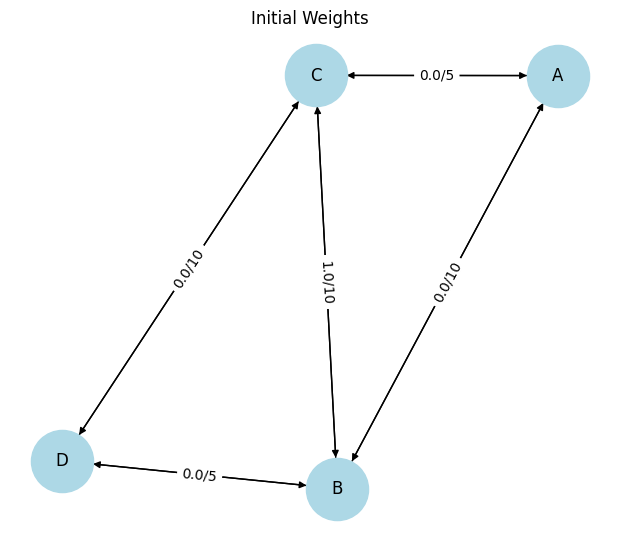

In [5]:
route_demands(G, demands, ecmp=False)

util_df = compute_utilization(G)
print("=== Link Utilization ===")
display(util_df)

print("Max Utilization:", util_df["utilization"].max())

draw_graph(G, title="Initial Weights")

### Weight Adjustment Experiment

=== After Weight Change ===


,link,usage,capacity,utilization
3,B->C,9,10,0.9
7,C->D,7,10,0.7
0,A->B,6,10,0.6
6,C->B,1,10,0.1
1,A->C,0,5,0.0
2,B->A,0,10,0.0
5,C->A,0,5,0.0
4,B->D,0,5,0.0
8,D->B,0,5,0.0
9,D->C,0,10,0.0


Max Utilization: 0.9


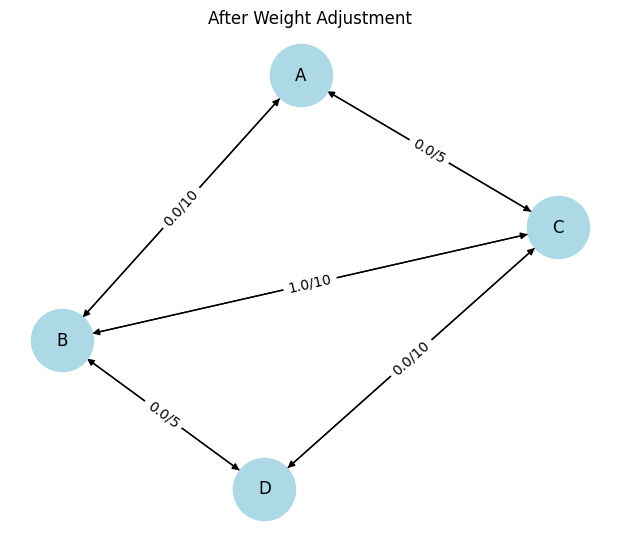

In [6]:
# Adjust weight to avoid congestion
G["B"]["D"]["weight"] = 5  # from 2 → 5

route_demands(G, demands, ecmp=False)

util_df2 = compute_utilization(G)
print("=== After Weight Change ===")
display(util_df2)

print("Max Utilization:", util_df2["utilization"].max())

draw_graph(G, title="After Weight Adjustment")